Performa Operasional Dan Emisi Carbon Green Quantum Data Center

Kelompok: 09

1. Fachri Addin Al Fikri (5027261009)
2. Raaif Mabkhud Nahdi (5027261042)
3. Qurrataaini Aghnia Sutino (5027261097)

Topik : Cloud Computing

**Latar belakang dan pertanyaan**


In [1]:
import pandas as pd

df = pd.read_csv("data/green_quantum_data_centers.csv") # Memuat dataset csv dari folder data

print('Ukuran dataset: %d baris dan %d kolom\n' % df.shape)

display(df.head())  # Memuat 5 baris dataset dari folder data

print("Penjelasan: Setiap baris mewakili satu catatan instans operasional atau tugas tunggal di pusat data.\n") #Jelaskan secara singkat: setiap baris mewakili apa? 

Ukuran dataset: 1000 baris dan 6 kolom



,workload_type,compute_demand_TFlops,storage_demand_TB,network_demand_Gbps,energy_source,carbon_emissions_kgCO2
0,Cloud Storage,408.32,62.95,67.84,Grid,1113.58
1,Cloud Storage,499.86,122.46,82.93,Wind,310.16
2,Database Queries,498.35,143.51,29.81,Hybrid,1398.70
3,Cloud Storage,282.16,55.25,1.92,Hybrid,1600.27
4,Web Hosting,386.80,83.30,73.92,Hybrid,368.54


Penjelasan: Setiap baris mewakili satu catatan instans operasional atau tugas tunggal di pusat data.



- **Sumber Data:** ([Kaggle](https://www.kaggle.com/datasets/zara2099/green-quantum-data-center-operations))
- **Lisensi:** ([CC0: Public Domain](https://creativecommons.org/publicdomain/zero/1.0/))
- Penulis : zara2099 Kapan : Last update 1 tahun yang lalu Bagaimana : Tidak ada penjelasan jelas di kaggle
- Jumlah Baris : 1000 dan Kolom : 6
- **Kamus Data:**<br>
|Kolom|Arti|Jenis variabel|Skala|Satuan|Contoh|
|-----|-------|------|-----|-------|------|
| workload_type | Jenis beban kerja pusat data | Kategorik | Nominal | – | Cloud Storage |
| energy_source | Sumber energi utama operasional | Kategorik | Nominal | – | Grid / Wind |
| compute_demand_TFlops | Besarnya permintaan komputasi | Numerik | Rasio | TFLOPs | 408.32 |
| storage_demand_TB | Kapasitas penyimpanan data | Numerik | Rasio | TB | 62.95 |
| network_demand_Gbps | Tingkat permintaan jaringan | Numerik | Rasio | Gbps | 67.84 |
| carbon_emissions_kgCO2` | Jumlah emisi karbon yang dihasilkan | Numerik | Rasio | kgCO2 | 1113.58 |
  

In [2]:
#Pemeriksaan kualitas data
print("--- tipe data setiap kolom ---")
df.info()

print("\n--- jumlah data kosong per kolom ---")
print(df.isna().sum())

print("\n--- jumlah baris duplikat ---")
print(df.duplicated().sum())

print("\n\033[1mKarena data sudah bersih tidak diperlukan tindakan pembersihan (cleaning)\033[0m")

--- tipe data setiap kolom ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   workload_type           1000 non-null   str    
 1   compute_demand_TFlops   1000 non-null   float64
 2   storage_demand_TB       1000 non-null   float64
 3   network_demand_Gbps     1000 non-null   float64
 4   energy_source           1000 non-null   str    
 5   carbon_emissions_kgCO2  1000 non-null   float64
dtypes: float64(4), str(2)
memory usage: 47.0 KB

--- jumlah data kosong per kolom ---
workload_type             0
compute_demand_TFlops     0
storage_demand_TB         0
network_demand_Gbps       0
energy_source             0
carbon_emissions_kgCO2    0
dtype: int64

--- jumlah baris duplikat ---
0

Karena data sudah bersih tidak diperlukan tindakan pembersihan (cleaning)


In [3]:
import pandas as pd


df.describe()



,compute_demand_TFlops,storage_demand_TB,network_demand_Gbps,carbon_emissions_kgCO2
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,253.231160,100.609740,50.257720,1023.278490
std,142.596825,57.154813,28.891489,571.351923
min,12.270000,1.310000,0.500000,57.640000
25%,125.362500,52.210000,25.262500,515.975000
50%,253.870000,101.860000,50.825000,1027.680000
75%,374.715000,149.517500,75.022500,1529.842500
max,499.860000,199.670000,99.890000,1998.950000


In [4]:
df["energy_source"].value_counts()
df["energy_source"].value_counts(normalize=True) * 100

energy_source
Hybrid    25.9
Grid      25.4
Wind      24.5
Solar     24.2
Name: proportion, dtype: float64

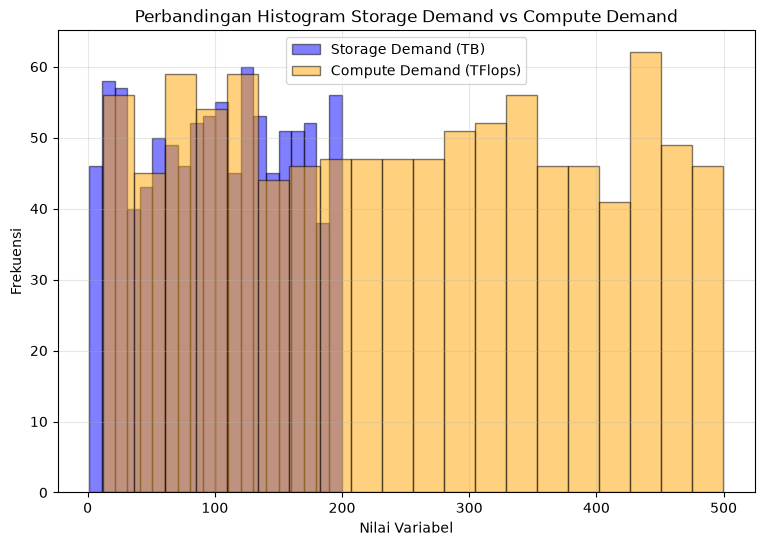

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# Histogram kolom pertama dengan transparansi (alpha=0.5)
plt.hist(df["storage_demand_TB"], bins=20, alpha=0.5, label='Storage Demand (TB)', color='blue', edgecolor='black')

# Histogram kolom kedua dalam satu grafik yang sama
plt.hist(df["compute_demand_TFlops"], bins=20, alpha=0.5, label='Compute Demand (TFlops)', color='orange', edgecolor='black')

plt.title("Perbandingan Histogram Storage Demand vs Compute Demand")
plt.xlabel("Nilai Variabel")
plt.ylabel("Frekuensi")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

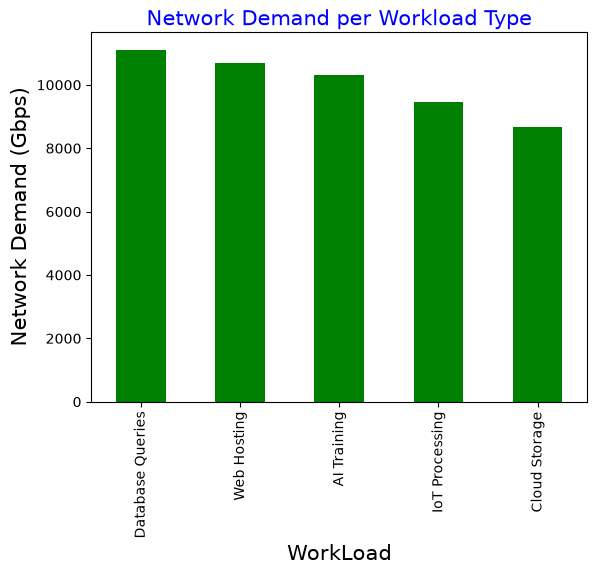

In [6]:
import matplotlib.pyplot as plt
plt.clf()
df.groupby('workload_type')['network_demand_Gbps'].sum().sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('Network Demand per Workload Type', loc='center',pad=5,fontsize=15,color='blue')
plt.xlabel('WorkLoad', fontsize=15)
plt.ylabel('Network Demand (Gbps)',fontsize=15)
plt.ylim(ymin=0)
labels, locations = plt.yticks()
plt.xticks()
plt.show()

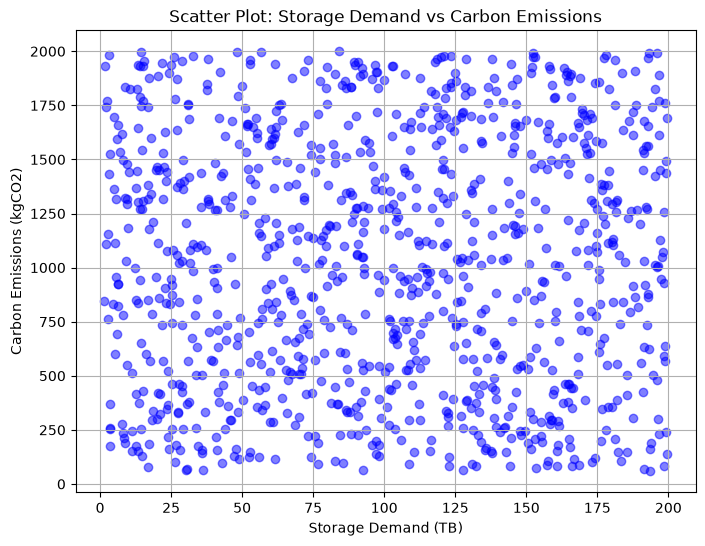

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df['storage_demand_TB'], df['carbon_emissions_kgCO2'], color='blue', alpha=0.5)
plt.title("Scatter Plot: Storage Demand vs Carbon Emissions")
plt.xlabel("Storage Demand (TB)")
plt.ylabel("Carbon Emissions (kgCO2)")
plt.grid(True)
plt.show()
